<a href="https://colab.research.google.com/github/dharnidhar9/Dharnidhar-Thakur/blob/readme-edits/kernelPCA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install numpy pandas scikit-learn matplotlib tensorflow keras layers
!pip install ta
!pip install pandas_ta
!wget http://prdownloads.sourceforge.net/ta-lib/ta-lib-0.4.0-src.tar.gz
!pip install tensorflow

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Created wheel for layers: filename=layers-0.1.5-py3-none-any.whl size=5354 sha256=3650e92a207dcdfcfa4b134b578546728ca88d17d504233ac7106cb7b48634f1
  Stored in directory: /root/.cache/pip/wheels/68/7e/9a/eef1bfd14949d8154d75aaa90cb20916e5b3e706ccab344690
  Created wheel for bashutils: filename=Bashutils-0.0.4-py3-none-any.whl size=5460 sha256=db8409a6ca703c04e6750208652fe2f320f77b791847fd702e047f73a69e2d21
  Stored in directory: /root/.cache/pip/wheels/25/49/d6/964f90673b8cb71f4a9fd6b19fdf69321c355bc1b48b0b5094
Successfully built layers bashutils
  Preparing metadata (setup.py) ... done
  Created wheel for ta: filename=ta-0.11.0-py3-none-any.whl size=29412 sha256=2f6414f79699d032196a9153c84d58186ba7e7fd6e8c1d30fdfe355cc0ff2fd5
  Stored in directory: /root/.cache/pip/wheels/5f/67/4f/8a9f252836e053e532c6587a3230bc72a4deb16b03a829610b
Successfully built ta
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.1

In [3]:
#import all required libraries
import math
import numpy as np
import pandas as pd
from pandas_ta import Imports
from pandas_ta.utils import get_offset, verify_series
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
#Read the data of nbl
stock_data = pd.read_csv('/content/UPPER.csv')
stock_data

,Date,Open_price,Max_Price,Min_Price,Close_Price,Total_Traded Shares
0,4/15/2019,233.0,233.0,226.0,230.0,31609
1,4/16/2019,230.0,234.0,228.0,230.0,31491
2,4/17/2019,230.0,232.0,228.0,229.0,36025
3,4/18/2019,231.0,231.0,227.0,229.0,23918
4,4/21/2019,229.0,229.0,225.0,228.0,29902
...,...,...,...,...,...,...
1127,4/3/2024,173.6,173.6,168.1,169.6,169746
1128,4/4/2024,172.9,172.9,168.0,169.0,160768
1129,4/7/2024,170.0,171.0,168.3,170.9,174686
1130,4/9/2024,170.0,174.6,170.0,172.8,184830


In [ ]:
#to calculate Technical Indicator
#create function to calculate Simple Moving Average
#stock_data = stock_data['Close_Price'].to_frame()
# Calculate 30-day Simple Moving Average (SMA)
stock_data['SMA5'] = stock_data['Close_Price'].rolling(5).mean()
stock_data['SMA10'] = stock_data['Close_Price'].rolling(10).mean()
stock_data['SMA15'] = stock_data['Close_Price'].rolling(15).mean()
stock_data['SMA20'] = stock_data['Close_Price'].rolling(20).mean()

# Remove NULL values
stock_data.dropna(inplace=True)

stock_data

,Date,Open_price,Max_Price,Min_Price,Close_Price,Total_Traded Shares,SMA5,SMA10,SMA15,SMA20
19,5/13/2019,232.0,244.0,231.0,244.0,91650,236.60,237.90,235.400000,233.850
20,5/14/2019,247.0,254.0,244.0,249.0,127228,238.80,239.00,236.666667,234.800
21,5/15/2019,248.0,254.0,246.0,246.0,59616,241.20,239.20,237.733333,235.600
22,5/16/2019,245.0,249.0,244.0,246.0,49168,243.60,239.60,238.933333,236.450
23,5/19/2019,246.0,247.0,243.0,245.0,32329,246.00,240.50,240.133333,237.250
...,...,...,...,...,...,...,...,...,...,...
1127,4/3/2024,173.6,173.6,168.1,169.6,169746,171.98,174.78,177.633333,184.515
1128,4/4/2024,172.9,172.9,168.0,169.0,160768,170.78,173.67,176.660000,182.715
1129,4/7/2024,170.0,171.0,168.3,170.9,174686,170.24,172.81,175.526667,181.010
1130,4/9/2024,170.0,174.6,170.0,172.8,184830,170.50,172.49,174.860000,179.310


In [ ]:
#To calculate the Cumulative moving average
stock_data['CMA20'] = stock_data['Close_Price'].expanding().mean()
stock_data

,Date,Open_price,Max_Price,Min_Price,Close_Price,Total_Traded Shares,SMA5,SMA10,SMA15,SMA20,CMA20
19,5/13/2019,232.0,244.0,231.0,244.0,91650,236.60,237.90,235.400000,233.850,244.000000
20,5/14/2019,247.0,254.0,244.0,249.0,127228,238.80,239.00,236.666667,234.800,246.500000
21,5/15/2019,248.0,254.0,246.0,246.0,59616,241.20,239.20,237.733333,235.600,246.333333
22,5/16/2019,245.0,249.0,244.0,246.0,49168,243.60,239.60,238.933333,236.450,246.250000
23,5/19/2019,246.0,247.0,243.0,245.0,32329,246.00,240.50,240.133333,237.250,246.000000
...,...,...,...,...,...,...,...,...,...,...,...
1127,4/3/2024,173.6,173.6,168.1,169.6,169746,171.98,174.78,177.633333,184.515,424.811542
1128,4/4/2024,172.9,172.9,168.0,169.0,160768,170.78,173.67,176.660000,182.715,424.581081
1129,4/7/2024,170.0,171.0,168.3,170.9,174686,170.24,172.81,175.526667,181.010,424.352745
1130,4/9/2024,170.0,174.6,170.0,172.8,184830,170.50,172.49,174.860000,179.310,424.126529


In [ ]:
#To calculate the Exponential moving average
stock_data['EWMA5'] = stock_data['Close_Price'].ewm(span=5).mean()
stock_data['EWMA10'] = stock_data['Close_Price'].ewm(span=10).mean()
stock_data['EWMA15'] = stock_data['Close_Price'].ewm(span=15).mean()
stock_data['EWMA20'] = stock_data['Close_Price'].ewm(span=20).mean()
stock_data.dropna(inplace=True)
stock_data

,Date,Open_price,Max_Price,Min_Price,Close_Price,Total_Traded Shares,SMA5,SMA10,SMA15,SMA20,CMA20,EWMA5,EWMA10,EWMA15,EWMA20
19,5/13/2019,232.0,244.0,231.0,244.0,91650,236.60,237.90,235.400000,233.850,244.000000,244.000000,244.000000,244.000000,244.000000
20,5/14/2019,247.0,254.0,244.0,249.0,127228,238.80,239.00,236.666667,234.800,246.500000,247.000000,246.750000,246.666667,246.625000
21,5/15/2019,248.0,254.0,246.0,246.0,59616,241.20,239.20,237.733333,235.600,246.333333,246.526316,246.448505,246.414201,246.395504
22,5/16/2019,245.0,249.0,244.0,246.0,49168,243.60,239.60,238.933333,236.450,246.250000,246.307692,246.300743,246.289086,246.281328
23,5/19/2019,246.0,247.0,243.0,245.0,32329,246.00,240.50,240.133333,237.250,246.000000,245.805687,245.927335,245.958273,245.971386
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1127,4/3/2024,173.6,173.6,168.1,169.6,169746,171.98,174.78,177.633333,184.515,424.811542,171.850866,175.350811,178.964537,182.221055
1128,4/4/2024,172.9,172.9,168.0,169.0,160768,170.78,173.67,176.660000,182.715,424.581081,170.900577,174.196118,177.718969,180.961907
1129,4/7/2024,170.0,171.0,168.3,170.9,174686,170.24,172.81,175.526667,181.010,424.352745,170.900385,173.596824,176.866598,180.003630
1130,4/9/2024,170.0,174.6,170.0,172.8,184830,170.50,172.49,174.860000,179.310,424.126529,171.533590,173.451947,176.358273,179.317570


In [ ]:
#To calulate the MACD moving average convergance/divergance(MACD)
k = stock_data['Close_Price'].ewm(span=12, adjust=False, min_periods=12).mean()
d = stock_data['Close_Price'].ewm(span=26, adjust=False, min_periods=26).mean()
MACD = k-d
macd_s = MACD.ewm(span=9, adjust=False, min_periods=9).mean()
macd_h = MACD - macd_s
stock_data['MACD'] = stock_data.index.map(MACD)
stock_data['macd_h'] = stock_data.index.map(macd_h)
stock_data['macd_s'] = stock_data.index.map(macd_s)
# Remove NULL values
stock_data.dropna(inplace=True)
stock_data

,Date,Open_price,Max_Price,Min_Price,Close_Price,Total_Traded Shares,SMA5,SMA10,SMA15,SMA20,CMA20,EWMA5,EWMA10,EWMA15,EWMA20,MACD,macd_h,macd_s
52,7/1/2019,264.0,267.0,263.0,265.0,20100,265.80,266.40,265.933333,268.700,268.970588,265.527607,266.380425,267.263652,267.898602,0.090598,-0.693900,0.784498
53,7/2/2019,265.0,266.0,263.0,266.0,27581,265.40,266.30,265.733333,267.700,268.885714,265.685071,266.311195,267.104207,267.712169,0.029905,-0.603674,0.633580
54,7/3/2019,271.0,271.0,264.0,270.0,41945,266.40,266.70,265.933333,267.250,268.916667,267.123381,266.982376,267.469163,267.936160,0.301102,-0.265982,0.567084
55,7/4/2019,270.0,270.0,267.0,268.0,20959,266.60,266.60,266.266667,266.850,268.891892,267.415588,267.167509,267.535995,267.942393,0.350602,-0.173185,0.523788
56,7/7/2019,265.0,268.0,265.0,266.0,25900,267.00,266.70,266.733333,266.400,268.815789,266.943725,266.955131,267.342787,267.753184,0.225845,-0.238354,0.464199
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1127,4/3/2024,173.6,173.6,168.1,169.6,169746,171.98,174.78,177.633333,184.515,424.811542,171.850866,175.350811,178.964537,182.221055,-8.714891,-0.744240,-7.970651
1128,4/4/2024,172.9,172.9,168.0,169.0,160768,170.78,173.67,176.660000,182.715,424.581081,170.900577,174.196118,177.718969,180.961907,-8.693341,-0.578152,-8.115189
1129,4/7/2024,170.0,171.0,168.3,170.9,174686,170.24,172.81,175.526667,181.010,424.352745,170.900385,173.596824,176.866598,180.003630,-8.425821,-0.248505,-8.177315
1130,4/9/2024,170.0,174.6,170.0,172.8,184830,170.50,172.49,174.860000,179.310,424.126529,171.533590,173.451947,176.358273,179.317570,-7.968637,0.166943,-8.135580


In [ ]:
#to calculate RSI
# Calculate gains and losses
delta = stock_data['Close_Price'].diff()
gain = delta.where(delta > 0, 0)
loss = -delta.where(delta < 0, 0)

# Calculate average gain and loss
avg_gain = gain.ewm(com=13, adjust=False).mean()
stock_data['AVG_Gain'] = avg_gain
avg_loss = loss.ewm(com=13, adjust=False).mean()
stock_data['AVG_Loss'] = avg_loss
# Calculate RSI
rs = avg_gain / avg_loss.abs()
rsi = 100 - (100 / (1 + rs))
stock_data['RSI'] = rsi
# Remove NULL values
stock_data.dropna(inplace=True)
stock_data

,Date,Open_price,Max_Price,Min_Price,Close_Price,Total_Traded Shares,SMA5,SMA10,SMA15,SMA20,...,EWMA5,EWMA10,EWMA15,EWMA20,MACD,macd_h,macd_s,AVG_Gain,AVG_Loss,RSI
53,7/2/2019,265.0,266.0,263.0,266.0,27581,265.40,266.30,265.733333,267.700,...,265.685071,266.311195,267.104207,267.712169,0.029905,-0.603674,0.633580,0.071429,-0.000000,100.000000
54,7/3/2019,271.0,271.0,264.0,270.0,41945,266.40,266.70,265.933333,267.250,...,267.123381,266.982376,267.469163,267.936160,0.301102,-0.265982,0.567084,0.352041,-0.000000,100.000000
55,7/4/2019,270.0,270.0,267.0,268.0,20959,266.60,266.60,266.266667,266.850,...,267.415588,267.167509,267.535995,267.942393,0.350602,-0.173185,0.523788,0.326895,0.142857,69.588829
56,7/7/2019,265.0,268.0,265.0,266.0,25900,267.00,266.70,266.733333,266.400,...,266.943725,266.955131,267.342787,267.753184,0.225845,-0.238354,0.464199,0.303545,0.275510,52.420769
57,7/8/2019,275.0,275.0,263.0,265.0,27996,267.00,266.40,266.600000,266.200,...,266.295817,266.599511,267.048327,267.485577,0.045755,-0.334755,0.380510,0.281864,0.327259,46.273668
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1127,4/3/2024,173.6,173.6,168.1,169.6,169746,171.98,174.78,177.633333,184.515,...,171.850866,175.350811,178.964537,182.221055,-8.714891,-0.744240,-7.970651,0.734483,1.998310,26.876651
1128,4/4/2024,172.9,172.9,168.0,169.0,160768,170.78,173.67,176.660000,182.715,...,170.900577,174.196118,177.718969,180.961907,-8.693341,-0.578152,-8.115189,0.682020,1.898431,26.430273
1129,4/7/2024,170.0,171.0,168.3,170.9,174686,170.24,172.81,175.526667,181.010,...,170.900385,173.596824,176.866598,180.003630,-8.425821,-0.248505,-8.177315,0.769019,1.762829,30.373821
1130,4/9/2024,170.0,174.6,170.0,172.8,184830,170.50,172.49,174.860000,179.310,...,171.533590,173.451947,176.358273,179.317570,-7.968637,0.166943,-8.135580,0.849803,1.636912,34.173720


In [ ]:
# To Calculate moving average and standard deviation
window = 20 # Number of periods to use for moving average and standard deviation
rolling_mean = stock_data['Close_Price'].rolling(window).mean()
rolling_std = stock_data['Close_Price'].rolling(window).std()

# Calculate upper and lower bands
upper_band = rolling_mean + (rolling_std * 2)
stock_data['Bollinger upper band'] = upper_band
lower_band = rolling_mean - (rolling_std * 2)
middle_band = (upper_band + lower_band)/2
stock_data['Bollinger middle band'] = middle_band
stock_data['Bollinger Lower band'] = lower_band
stock_data.dropna(inplace=True)
stock_data

,Date,Open_price,Max_Price,Min_Price,Close_Price,Total_Traded Shares,SMA5,SMA10,SMA15,SMA20,...,EWMA20,MACD,macd_h,macd_s,AVG_Gain,AVG_Loss,RSI,Bollinger upper band,Bollinger middle band,Bollinger Lower band
72,8/1/2019,273.0,275.0,270.0,271.0,29663,277.20,279.20,275.800000,273.600,...,274.667895,2.491226,-0.545877,3.037104,1.130992,1.280463,46.900821,287.969558,273.600,259.230442
73,8/4/2019,272.0,272.0,268.0,268.0,24121,274.00,278.50,276.000000,273.700,...,274.030263,1.673008,-1.091277,2.764285,1.050207,1.403287,42.804549,287.873363,273.700,259.526637
74,8/5/2019,269.0,269.0,266.0,267.0,24786,270.80,276.60,276.000000,273.550,...,273.358241,0.933116,-1.464935,2.398051,0.975192,1.374480,41.503317,287.949927,273.550,259.150073
75,8/6/2019,266.0,267.0,264.0,266.0,28077,269.00,274.90,275.933333,273.450,...,272.655115,0.263023,-1.708022,1.971045,0.905535,1.347732,40.187662,288.038748,273.450,258.861252
76,8/7/2019,263.0,268.0,262.0,268.0,17127,268.00,273.80,275.800000,273.550,...,272.210431,-0.105432,-1.661182,1.555750,0.983711,1.251465,44.010456,287.949927,273.550,259.150073
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1127,4/3/2024,173.6,173.6,168.1,169.6,169746,171.98,174.78,177.633333,184.515,...,182.221055,-8.714891,-0.744240,-7.970651,0.734483,1.998310,26.876651,210.621605,184.515,158.408395
1128,4/4/2024,172.9,172.9,168.0,169.0,160768,170.78,173.67,176.660000,182.715,...,180.961907,-8.693341,-0.578152,-8.115189,0.682020,1.898431,26.430273,207.819688,182.715,157.610312
1129,4/7/2024,170.0,171.0,168.3,170.9,174686,170.24,172.81,175.526667,181.010,...,180.003630,-8.425821,-0.248505,-8.177315,0.769019,1.762829,30.373821,204.308963,181.010,157.711037
1130,4/9/2024,170.0,174.6,170.0,172.8,184830,170.50,172.49,174.860000,179.310,...,179.317570,-7.968637,0.166943,-8.135580,0.849803,1.636912,34.173720,199.430573,179.310,159.189427


In [ ]:
#To calculate the Williams %R
def get_wr(Max_Price, Min_Price, Close_Price, lookback):
    highh = Max_Price.rolling(lookback).max()
    lowl = Min_Price.rolling(lookback).min()
    wr = -100 * ((highh - Close_Price) / (highh - lowl))
    return wr

stock_data['wr_14'] = get_wr(stock_data['Max_Price'], stock_data['Min_Price'], stock_data['Close_Price'], 14)
stock_data.dropna(inplace=True)
stock_data

,Date,Open_price,Max_Price,Min_Price,Close_Price,Total_Traded Shares,SMA5,SMA10,SMA15,SMA20,...,MACD,macd_h,macd_s,AVG_Gain,AVG_Loss,RSI,Bollinger upper band,Bollinger middle band,Bollinger Lower band,wr_14
85,8/20/2019,258.0,259.0,253.0,253.0,27337,259.00,262.40,264.600000,268.650,...,-3.771336,-1.799276,-1.972059,0.550690,1.580034,25.845194,285.967773,268.650,251.332227,-100.000000
86,8/21/2019,254.0,259.0,254.0,255.0,20215,257.00,261.10,263.400000,267.450,...,-4.099995,-1.702349,-2.397647,0.654212,1.467174,30.838885,285.071458,267.450,249.828542,-89.473684
87,8/22/2019,255.0,258.0,252.0,255.0,16248,255.80,259.90,262.333333,266.050,...,-4.310769,-1.530498,-2.780271,0.607482,1.362376,30.838885,282.901987,266.050,249.198013,-82.352941
88,8/25/2019,251.0,254.0,248.0,250.0,44153,254.20,258.50,261.133333,264.350,...,-4.825639,-1.636294,-3.189345,0.564091,1.622206,25.801194,280.419258,264.350,248.280742,-90.000000
89,8/26/2019,247.0,253.0,247.0,249.0,20410,252.40,256.90,259.933333,262.650,...,-5.253807,-1.651570,-3.602237,0.523799,1.577763,24.924255,277.564140,262.650,247.735860,-90.476190
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1127,4/3/2024,173.6,173.6,168.1,169.6,169746,171.98,174.78,177.633333,184.515,...,-8.714891,-0.744240,-7.970651,0.734483,1.998310,26.876651,210.621605,184.515,158.408395,-93.362832
1128,4/4/2024,172.9,172.9,168.0,169.0,160768,170.78,173.67,176.660000,182.715,...,-8.693341,-0.578152,-8.115189,0.682020,1.898431,26.430273,207.819688,182.715,157.610312,-95.454545
1129,4/7/2024,170.0,171.0,168.3,170.9,174686,170.24,172.81,175.526667,181.010,...,-8.425821,-0.248505,-8.177315,0.769019,1.762829,30.373821,204.308963,181.010,157.711037,-82.317073
1130,4/9/2024,170.0,174.6,170.0,172.8,184830,170.50,172.49,174.860000,179.310,...,-7.968637,0.166943,-8.135580,0.849803,1.636912,34.173720,199.430573,179.310,159.189427,-70.731707


In [ ]:
# Function to calculate Stochastic Oscillator
def stochastic_oscillator(stock_data, period_k, period_d):
    # Calculate the highest high and lowest low over the period
    high_max = stock_data['Max_Price'].rolling(window=period_k).max()
    low_min = stock_data['Min_Price'].rolling(window=period_k).min()

    # Calculate %K
    stock_data['%K'] = ((stock_data['Close_Price'] - low_min) / (high_max - low_min)) * 100

    # Calculate %D (smoothed %K)
    stock_data['%D'] = stock_data['%K'].rolling(window=period_d).mean()

    return stock_data[['Date', '%K', '%D']]

# Calculate Stochastic Oscillator with periods of 14 for %K and 3 for %D
stochastic_data = stochastic_oscillator(stock_data, 14, 3)
stock_data.dropna(inplace=True)
stock_data

,Date,Open_price,Max_Price,Min_Price,Close_Price,Total_Traded Shares,SMA5,SMA10,SMA15,SMA20,...,macd_s,AVG_Gain,AVG_Loss,RSI,Bollinger upper band,Bollinger middle band,Bollinger Lower band,wr_14,%K,%D
100,9/10/2019,241.0,245.0,238.0,240.0,12852,243.60,244.70,247.200000,250.150,...,-5.894812,0.641187,1.616655,28.398234,263.888536,250.150,236.411464,-90.000000,10.000000,17.619048
101,9/11/2019,242.0,242.0,238.0,239.0,13161,241.80,243.80,246.133333,248.850,...,-5.989872,0.595388,1.572609,27.462603,261.553501,248.850,236.146499,-94.736842,5.263158,9.849624
102,9/12/2019,239.0,242.0,236.0,237.0,15828,240.20,242.70,244.933333,247.650,...,-6.099372,0.552861,1.603136,25.642921,260.051613,247.650,235.248387,-95.238095,4.761905,6.675021
103,9/15/2019,238.0,238.0,232.0,235.0,17007,238.40,241.60,243.933333,246.500,...,-6.230189,0.513371,1.631484,23.934985,259.124121,246.500,233.875879,-88.000000,12.000000,7.341688
104,9/16/2019,235.0,236.0,230.0,231.0,23812,236.40,240.50,242.733333,245.150,...,-6.417128,0.476701,1.800664,20.932143,258.357255,245.150,231.942745,-96.296296,3.703704,6.821869
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1127,4/3/2024,173.6,173.6,168.1,169.6,169746,171.98,174.78,177.633333,184.515,...,-7.970651,0.734483,1.998310,26.876651,210.621605,184.515,158.408395,-93.362832,6.637168,4.931283
1128,4/4/2024,172.9,172.9,168.0,169.0,160768,170.78,173.67,176.660000,182.715,...,-8.115189,0.682020,1.898431,26.430273,207.819688,182.715,157.610312,-95.454545,4.545455,5.017863
1129,4/7/2024,170.0,171.0,168.3,170.9,174686,170.24,172.81,175.526667,181.010,...,-8.177315,0.769019,1.762829,30.373821,204.308963,181.010,157.711037,-82.317073,17.682927,9.621850
1130,4/9/2024,170.0,174.6,170.0,172.8,184830,170.50,172.49,174.860000,179.310,...,-8.135580,0.849803,1.636912,34.173720,199.430573,179.310,159.189427,-70.731707,29.268293,17.165558


In [ ]:
#To calculate the Know Sure Thing (KST)

# Function to calculate Rate of Change (ROC)
def rate_of_change(stock_data, period):
    return ((stock_data['Close_Price'] - stock_data['Close_Price'].shift(period)) / stock_data['Close_Price'].shift(period)) * 100

# Calculate Rate of Change for periods 10, 15, 20, and 30
stock_data['ROC_10'] = rate_of_change(stock_data, 10)
stock_data['ROC_15'] = rate_of_change(stock_data, 15)
stock_data['ROC_20'] = rate_of_change(stock_data, 20)
stock_data['ROC_30'] = rate_of_change(stock_data, 30)

# Function to calculate the Know Sure Thing (KST)
def kst(stock_data):
    kst_period_1 = stock_data['ROC_10'].rolling(window=6).mean()
    kst_period_2 = stock_data['ROC_15'].rolling(window=6).mean()
    kst_period_3 = stock_data['ROC_20'].rolling(window=6).mean()
    kst_period_4 = stock_data['ROC_30'].rolling(window=6).mean()
    return kst_period_1 * 1 + kst_period_2 * 2 + kst_period_3 * 3 + kst_period_4 * 4

# Calculate KST
stock_data['KST'] = kst(stock_data)

# Print the DataFrame with KST values
stock_data.dropna(inplace=True)
stock_data

,Date,Open_price,Max_Price,Min_Price,Close_Price,Total_Traded Shares,SMA5,SMA10,SMA15,SMA20,...,Bollinger middle band,Bollinger Lower band,wr_14,%K,%D,ROC_10,ROC_15,ROC_20,ROC_30,KST
135,11/12/2019,233.0,236.0,230.0,233.0,8130,233.40,234.90,235.466667,235.750,...,235.750,231.863451,-72.727273,27.272727,18.181818,-2.510460,-2.100840,-1.271186,-5.284553,-9.394873
136,11/13/2019,230.0,232.0,230.0,231.0,12774,232.40,234.20,235.066667,235.400,...,235.400,231.125227,-90.909091,9.090909,21.212121,-2.941176,-2.531646,-2.941176,-5.714286,-16.324531
137,11/14/2019,231.0,232.0,230.0,231.0,11056,231.80,233.70,234.733333,235.150,...,235.150,230.458462,-90.909091,9.090909,15.151515,-2.118644,-2.118644,-2.118644,-5.327869,-21.890083
138,11/17/2019,231.0,233.0,226.0,228.0,19706,231.20,233.00,234.200000,234.750,...,234.750,229.097800,-86.666667,13.333333,10.505051,-2.978723,-3.389831,-3.389831,-2.978723,-27.021303
139,11/18/2019,228.0,228.0,226.0,228.0,12226,230.20,232.20,233.733333,234.400,...,234.400,227.996054,-85.714286,14.285714,12.236652,-3.389831,-2.978723,-2.978723,-4.201681,-29.409768
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1127,4/3/2024,173.6,173.6,168.1,169.6,169746,171.98,174.78,177.633333,184.515,...,184.515,158.408395,-93.362832,6.637168,4.931283,-6.194690,-16.862745,-20.821662,-17.308630,-157.128776
1128,4/4/2024,172.9,172.9,168.0,169.0,160768,170.78,173.67,176.660000,182.715,...,182.715,157.610312,-95.454545,4.545455,5.017863,-6.163243,-7.952070,-17.560976,-17.359413,-153.496657
1129,4/7/2024,170.0,171.0,168.3,170.9,174686,170.24,172.81,175.526667,181.010,...,181.010,157.711037,-82.317073,17.682927,9.621850,-4.791086,-9.047366,-16.634146,-15.812808,-151.173684
1130,4/9/2024,170.0,174.6,170.0,172.8,184830,170.50,172.49,174.860000,179.310,...,179.310,159.189427,-70.731707,29.268293,17.165558,-1.818182,-5.470460,-16.441006,-13.122172,-145.219251


In [ ]:
# Function to calculate Chande Momentum Oscillator (CMO)
def cmo(stock_data, period):
    typical_price = (stock_data['Max_Price'] + stock_data['Min_Price'] + stock_data['Close_Price']) / 3
    diff_typical_price = typical_price - typical_price.shift(1)

    # Calculate gains and losses
    gains = diff_typical_price.where(diff_typical_price > 0, 0).rolling(window=period).sum()
    losses = abs(diff_typical_price.where(diff_typical_price < 0, 0).rolling(window=period).sum())

    # Calculate CMO
    cmo = ((gains - losses) / (gains + losses)) * 100
    return cmo

# Calculate CMO with a period of 14 days
stock_data['CMO'] = cmo(stock_data, 14)

# Print the DataFrame with CMO values
# print(stock_data[['Date', 'CMO']])
stock_data.dropna(inplace=True)
stock_data

,Date,Open_price,Max_Price,Min_Price,Close_Price,Total_Traded Shares,SMA5,SMA10,SMA15,SMA20,...,Bollinger Lower band,wr_14,%K,%D,ROC_10,ROC_15,ROC_20,ROC_30,KST,CMO
148,12/1/2019,224.0,230.0,223.0,226.0,8886,225.60,225.60,227.466667,229.300,...,220.448001,-66.666667,33.333333,28.888889,-0.877193,-2.164502,-3.829787,-4.237288,-44.611049,-43.478261
149,12/2/2019,226.0,231.0,225.0,231.0,9863,226.60,225.90,227.333333,229.050,...,220.728183,-16.666667,83.333333,45.555556,1.315789,-0.858369,-2.118644,-1.702128,-37.900266,-22.222222
150,12/3/2019,227.0,232.0,225.0,230.0,12396,227.40,226.20,227.133333,228.700,...,221.242048,-25.000000,75.000000,63.888889,1.321586,-1.287554,-2.953586,-3.361345,-34.904604,-12.500000
151,12/4/2019,229.0,235.0,228.0,232.0,12012,228.60,226.70,227.200000,228.500,...,221.678980,-21.428571,78.571429,78.968254,2.202643,0.432900,-1.694915,-2.109705,-29.054768,3.571429
152,12/5/2019,232.0,236.0,232.0,236.0,15078,231.00,228.00,227.533333,228.600,...,221.391818,-0.000000,100.000000,84.523810,5.829596,2.164502,0.854701,0.000000,-19.278785,28.813559
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1127,4/3/2024,173.6,173.6,168.1,169.6,169746,171.98,174.78,177.633333,184.515,...,158.408395,-93.362832,6.637168,4.931283,-6.194690,-16.862745,-20.821662,-17.308630,-157.128776,-76.680384
1128,4/4/2024,172.9,172.9,168.0,169.0,160768,170.78,173.67,176.660000,182.715,...,157.610312,-95.454545,4.545455,5.017863,-6.163243,-7.952070,-17.560976,-17.359413,-153.496657,-69.479354
1129,4/7/2024,170.0,171.0,168.3,170.9,174686,170.24,172.81,175.526667,181.010,...,157.711037,-82.317073,17.682927,9.621850,-4.791086,-9.047366,-16.634146,-15.812808,-151.173684,-91.480730
1130,4/9/2024,170.0,174.6,170.0,172.8,184830,170.50,172.49,174.860000,179.310,...,159.189427,-70.731707,29.268293,17.165558,-1.818182,-5.470460,-16.441006,-13.122172,-145.219251,-57.630979


In [ ]:
#function to calculate Highest high

# Specify the period for the highest high calculation
period = 14  # You can adjust this period according to your requirement

# Calculate the highest high over the specified period
stock_data['Highest High'] = stock_data['Max_Price'].rolling(window=period).max()

# Print the DataFrame with the highest high values
# print(stock_data[['Date', 'Highest High']])
stock_data.dropna(inplace=True)
stock_data

,Date,Open_price,Max_Price,Min_Price,Close_Price,Total_Traded Shares,SMA5,SMA10,SMA15,SMA20,...,wr_14,%K,%D,ROC_10,ROC_15,ROC_20,ROC_30,KST,CMO,Highest High
161,12/18/2019,233.0,234.0,232.0,232.0,7141,237.00,236.10,233.600000,231.400,...,-71.875000,28.125000,32.954545,0.000000,2.654867,2.202643,-1.694915,25.799623,21.008403,255.0
162,12/19/2019,235.0,235.0,230.0,233.0,9157,234.60,235.80,234.200000,231.900,...,-73.333333,26.666667,29.722222,-1.271186,4.017857,4.484305,-0.427350,26.303220,16.814159,255.0
163,12/22/2019,230.0,235.0,229.0,232.0,10754,233.00,235.60,234.600000,232.350,...,-76.666667,23.333333,26.041667,-0.854701,2.654867,4.035874,0.432900,18.928597,8.411215,255.0
164,12/23/2019,233.0,237.0,231.0,235.0,18492,233.20,235.50,234.866667,232.800,...,-74.074074,25.925926,25.308642,-0.423729,1.731602,3.982301,0.858369,14.374999,14.035088,255.0
165,12/24/2019,236.0,247.0,235.0,237.0,46247,233.80,235.80,235.333333,233.350,...,-66.666667,33.333333,27.530864,1.282051,3.043478,4.867257,1.716738,17.034079,19.672131,255.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1127,4/3/2024,173.6,173.6,168.1,169.6,169746,171.98,174.78,177.633333,184.515,...,-93.362832,6.637168,4.931283,-6.194690,-16.862745,-20.821662,-17.308630,-157.128776,-76.680384,190.7
1128,4/4/2024,172.9,172.9,168.0,169.0,160768,170.78,173.67,176.660000,182.715,...,-95.454545,4.545455,5.017863,-6.163243,-7.952070,-17.560976,-17.359413,-153.496657,-69.479354,190.0
1129,4/7/2024,170.0,171.0,168.3,170.9,174686,170.24,172.81,175.526667,181.010,...,-82.317073,17.682927,9.621850,-4.791086,-9.047366,-16.634146,-15.812808,-151.173684,-91.480730,184.4
1130,4/9/2024,170.0,174.6,170.0,172.8,184830,170.50,172.49,174.860000,179.310,...,-70.731707,29.268293,17.165558,-1.818182,-5.470460,-16.441006,-13.122172,-145.219251,-57.630979,184.4


In [ ]:
# Specify the period for the lowest low calculation
period = 14  # You can adjust this period according to your requirement

# Calculate the lowest low over the specified period
stock_data['Lowest Low'] = stock_data['Min_Price'].rolling(window=period).min()

# Print the DataFrame with the lowest low values
# print(stock_data[['Date', 'Lowest Low']])
stock_data.dropna(inplace=True)
stock_data

,Date,Open_price,Max_Price,Min_Price,Close_Price,Total_Traded Shares,SMA5,SMA10,SMA15,SMA20,...,%K,%D,ROC_10,ROC_15,ROC_20,ROC_30,KST,CMO,Highest High,Lowest Low
174,1/6/2020,240.0,240.0,235.0,236.0,24393,236.20,236.10,235.133333,235.800,...,38.888889,42.592593,0.425532,0.854701,0.000000,4.424779,20.512133,20.754717,247.0,229.0
175,1/7/2020,236.0,245.0,236.0,241.0,42390,237.40,236.50,235.600000,236.150,...,66.666667,50.000000,1.687764,2.991453,2.991453,6.637168,26.311149,38.709677,247.0,229.0
176,1/8/2020,240.0,243.0,238.0,238.0,33470,237.80,236.50,236.000000,236.250,...,50.000000,51.851852,0.000000,2.586207,0.847458,5.309735,27.486652,32.307692,247.0,229.0
177,1/9/2020,242.0,242.0,236.0,238.0,18802,238.00,236.70,236.333333,235.900,...,43.750000,53.472222,0.847458,2.145923,-2.857143,6.250000,27.288701,30.303030,247.0,231.0
178,1/12/2020,238.0,246.0,236.0,243.0,42403,239.20,237.40,237.066667,236.050,...,73.333333,55.694444,2.966102,4.741379,1.250000,7.522124,31.408356,32.352941,247.0,232.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1127,4/3/2024,173.6,173.6,168.1,169.6,169746,171.98,174.78,177.633333,184.515,...,6.637168,4.931283,-6.194690,-16.862745,-20.821662,-17.308630,-157.128776,-76.680384,190.7,168.1
1128,4/4/2024,172.9,172.9,168.0,169.0,160768,170.78,173.67,176.660000,182.715,...,4.545455,5.017863,-6.163243,-7.952070,-17.560976,-17.359413,-153.496657,-69.479354,190.0,168.0
1129,4/7/2024,170.0,171.0,168.3,170.9,174686,170.24,172.81,175.526667,181.010,...,17.682927,9.621850,-4.791086,-9.047366,-16.634146,-15.812808,-151.173684,-91.480730,184.4,168.0
1130,4/9/2024,170.0,174.6,170.0,172.8,184830,170.50,172.49,174.860000,179.310,...,29.268293,17.165558,-1.818182,-5.470460,-16.441006,-13.122172,-145.219251,-57.630979,184.4,168.0


In [ ]:
#To calculate Money Flow Index(MFI)
def mfi(stock_data, period):
    # Calculate typical price
    typical_price = (stock_data['Max_Price'] + stock_data['Min_Price'] + stock_data['Close_Price']) / 3

    # Calculate raw money flow (RMF)
    raw_money_flow = typical_price * stock_data['Total_Traded Shares']

    # Determine whether the typical price increased or decreased compared to the previous period
    delta_typical_price = typical_price.diff()

    # Calculate positive money flow (PMF) and negative money flow (NMF)
    pmf = (delta_typical_price.where(delta_typical_price > 0, 0) * stock_data['Total_Traded Shares']).rolling(window=period).sum()
    nmf = (delta_typical_price.where(delta_typical_price < 0, 0) * stock_data['Total_Traded Shares']).rolling(window=period).sum()

    # Calculate money flow ratio (MFR)
    mfr = pmf / nmf

    # Calculate Money Flow Index (MFI)
    mfi = 100 - (100 / (1 + mfr))

    return mfi

# Calculate MFI with a period of 14 days
stock_data['MFI'] = mfi(stock_data, 14)

# Print the DataFrame with MFI values
# print(stock_data[['Date', 'MFI']])
stock_data.dropna(inplace=True)
stock_data

,Date,Open_price,Max_Price,Min_Price,Close_Price,Total_Traded Shares,SMA5,SMA10,SMA15,SMA20,...,%D,ROC_10,ROC_15,ROC_20,ROC_30,KST,CMO,Highest High,Lowest Low,MFI
187,1/23/2020,247.0,254.0,244.0,245.0,36395,253.80,250.90,246.600000,243.800,...,45.751634,2.941176,3.375527,3.813559,0.000000,71.593700,23.529412,269.0,235.0,140.059719
188,1/26/2020,245.0,245.0,238.0,239.0,27453,249.00,250.50,246.733333,243.950,...,26.559715,-1.646091,0.843882,1.271186,-0.416667,62.172628,7.006369,269.0,236.0,156.720306
189,1/27/2020,243.0,249.0,240.0,244.0,18145,246.80,250.00,247.266667,244.500,...,20.915033,-2.008032,3.389831,4.721030,4.273504,47.592305,7.006369,269.0,236.0,160.023258
190,1/28/2020,244.0,250.0,243.0,243.0,26924,244.00,249.30,247.400000,244.900,...,18.181818,-2.800000,0.829876,3.404255,3.846154,37.556782,10.828025,269.0,236.0,155.630063
191,1/29/2020,240.0,243.0,240.0,240.0,23498,242.20,248.40,247.533333,245.100,...,19.191919,-3.614458,0.840336,1.694915,3.448276,25.381608,4.191617,269.0,236.0,164.221108
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1127,4/3/2024,173.6,173.6,168.1,169.6,169746,171.98,174.78,177.633333,184.515,...,4.931283,-6.194690,-16.862745,-20.821662,-17.308630,-157.128776,-76.680384,190.7,168.1,-9.262038
1128,4/4/2024,172.9,172.9,168.0,169.0,160768,170.78,173.67,176.660000,182.715,...,5.017863,-6.163243,-7.952070,-17.560976,-17.359413,-153.496657,-69.479354,190.0,168.0,-55.333471
1129,4/7/2024,170.0,171.0,168.3,170.9,174686,170.24,172.81,175.526667,181.010,...,9.621850,-4.791086,-9.047366,-16.634146,-15.812808,-151.173684,-91.480730,184.4,168.0,-4.882439
1130,4/9/2024,170.0,174.6,170.0,172.8,184830,170.50,172.49,174.860000,179.310,...,17.165558,-1.818182,-5.470460,-16.441006,-13.122172,-145.219251,-57.630979,184.4,168.0,-35.557216


In [ ]:
features = ['Open_price','Max_Price','Min_Price','Close_Price','Total_Traded Shares','SMA5', 'SMA10', 'SMA15', 'SMA20','CMA20','EWMA5' ,'EWMA10', 'EWMA15', 'EWMA20' , 'MACD' , 'macd_h', 'macd_s', 'AVG_Gain', 'AVG_Loss'	, 'RSI', 'Bollinger upper band', 'Bollinger middle band' , 'Bollinger Lower band', 'wr_14' , '%K', '%D', 'ROC_10', 'ROC_15', 'ROC_20', 'ROC_30', 'KST', 'Highest High' ,	'Lowest Low' ,	'MFI']
X = stock_data[features]
X.dropna(inplace=True)
X

<ipython-input-18-10307fe50691>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X.dropna(inplace=True)


,Open_price,Max_Price,Min_Price,Close_Price,Total_Traded Shares,SMA5,SMA10,SMA15,SMA20,CMA20,...,%K,%D,ROC_10,ROC_15,ROC_20,ROC_30,KST,Highest High,Lowest Low,MFI
187,247.0,254.0,244.0,245.0,36395,253.80,250.90,246.600000,243.800,250.319527,...,29.411765,45.751634,2.941176,3.375527,3.813559,0.000000,71.593700,269.0,235.0,140.059719
188,245.0,245.0,238.0,239.0,27453,249.00,250.50,246.733333,243.950,250.252941,...,9.090909,26.559715,-1.646091,0.843882,1.271186,-0.416667,62.172628,269.0,236.0,156.720306
189,243.0,249.0,240.0,244.0,18145,246.80,250.00,247.266667,244.500,250.216374,...,24.242424,20.915033,-2.008032,3.389831,4.721030,4.273504,47.592305,269.0,236.0,160.023258
190,244.0,250.0,243.0,243.0,26924,244.00,249.30,247.400000,244.900,250.174419,...,21.212121,18.181818,-2.800000,0.829876,3.404255,3.846154,37.556782,269.0,236.0,155.630063
191,240.0,243.0,240.0,240.0,23498,242.20,248.40,247.533333,245.100,250.115607,...,12.121212,19.191919,-3.614458,0.840336,1.694915,3.448276,25.381608,269.0,236.0,164.221108
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1127,173.6,173.6,168.1,169.6,169746,171.98,174.78,177.633333,184.515,424.811542,...,6.637168,4.931283,-6.194690,-16.862745,-20.821662,-17.308630,-157.128776,190.7,168.1,-9.262038
1128,172.9,172.9,168.0,169.0,160768,170.78,173.67,176.660000,182.715,424.581081,...,4.545455,5.017863,-6.163243,-7.952070,-17.560976,-17.359413,-153.496657,190.0,168.0,-55.333471
1129,170.0,171.0,168.3,170.9,174686,170.24,172.81,175.526667,181.010,424.352745,...,17.682927,9.621850,-4.791086,-9.047366,-16.634146,-15.812808,-151.173684,184.4,168.0,-4.882439
1130,170.0,174.6,170.0,172.8,184830,170.50,172.49,174.860000,179.310,424.126529,...,29.268293,17.165558,-1.818182,-5.470460,-16.441006,-13.122172,-145.219251,184.4,168.0,-35.557216


In [ ]:
y = stock_data['Close_Price']
y

306     830.0
307     825.0
308     796.0
309     800.0
310     769.0
        ...  
2463    299.1
2464    296.1
2465    297.8
2466    300.0
2467    298.0
Name: Close_Price, Length: 2162, dtype: float64

In [ ]:
!pip install scikit-learn

In [ ]:
#For dimension reduction using kernel PCA
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import time

start_time = time.time()

#Preprocess the data (handle missing values, remove non-numeric columns, etc.)
# drop rows with missing values and remove non-numeric columns
X.dropna(inplace=True)
numeric_data = stock_data.select_dtypes(include=['number'])  # Keep only numeric columns

# Check if DataFrame is empty after dropping missing values
if numeric_data.empty:
    print("DataFrame is empty after dropping missing values or contains no numeric columns.")
else:
    # Scale the features
    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(numeric_data)

from sklearn.decomposition import KernelPCA

# Define KernelPCA with RBF kernel
rbf_pca = KernelPCA(n_components=1, kernel="rbf", gamma=0.04)

pca_result = rbf_pca.fit_transform(scaled_data)

# Since KernelPCA doesn't have a components_ attribute, you don't need to print it

# print("Principal Components Loadings:", pca.components_)


    # Use reduced dimension data
reduced_data = pd.DataFrame(data=pca_result, columns=['PCA1'])


print(reduced_data.head())

#for model evaluation

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.model_selection import train_test_split


# Shift the Close_Price by one day to align with the features
stock_data['Next_Day_Close_Price'] = stock_data['Close_Price'].shift(-1)
# Create sequences for LSTM
window_size = 60  # we can adjust this window size
def create_sequences(data, target, window_size):
    X = []
    y = []
    for i in range(len(data) - window_size):
        window = data[i:(i + window_size)]
        X.append(window)
        y.append(data[i + window_size])
    return np.array(X), np.array(y)
import numpy as np

X, y = create_sequences(reduced_data.values, stock_data['Next_Day_Close_Price'].values, window_size)


# Split the stock_data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define the LSTM model
model = Sequential([
    LSTM(50, activation='relu', input_shape=(window_size, reduced_data.shape[1])),
    Dense(reduced_data.shape[1])  # Output layer
])

# Compile the model
model.compile(optimizer='adam', loss='mse')

# Train the model
model.fit(X_train, y_train, epochs=100, batch_size=64, validation_data=(X_test, y_test))

# Evaluate the model
mse = model.evaluate(X_test, y_test)
print("Mean Squared Error:", mse)

end_time = time.time()
total_elapsed_time = end_time - start_time
print("Total Elapsed Time:", total_elapsed_time)

# Calculate RMSE
rmse = np.sqrt(mse)
print("Root Mean Squared Error:", rmse)


# Make predictions using the model
y_pred = model.predict(X_test)


from sklearn.metrics import mean_absolute_error

# Evaluate MAE
mae = mean_absolute_error(y_test, y_pred)
print("Mean Absolute Error:", mae)


#from sklearn.metrics import r2_score
# # Calculate the R2 coefficient
# r2 = r2_score(y_test, y_pred)

# print("R-squared (R2) coefficient:", r2)

# Make predictions
# predictions = model.predict(X_test)
end_time = time.time()
total_elapsed_time = end_time - start_time
print("Total Elapsed Time:", total_elapsed_time)

12/12 [==============================] - 0s 29ms/step - loss: 0.0032 - val_loss: 0.0030
Epoch 97/100
12/12 [==============================] - 0s 32ms/step - loss: 0.0030 - val_loss: 0.0026
Epoch 98/100
12/12 [==============================] - 0s 34ms/step - loss: 0.0029 - val_loss: 0.0026
Epoch 99/100
12/12 [==============================] - 0s 31ms/step - loss: 0.0027 - val_loss: 0.0141
Epoch 100/100
6/6 [==============================] - 0s 10ms/step - loss: 0.0062
Mean Squared Error: 0.006226770579814911
Total Elapsed Time: 85.36352705955505
Root Mean Squared Error: 0.07890988898620319
6/6 [==============================] - 0s 9ms/step
Mean Absolute Error: 0.06297950769261092
Total Elapsed Time: 85.72313642501831


In [ ]:
#for model evaluation
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.model_selection import train_test_split

# # # Create a DataFrame with the transformed data
# pca_result_df = pd.DataFrame(pca_result, columns=['PCA1','PCA2','PCA3','PCA4','PCA5'])

# # #'PCA1', 'PCA2','PCA3','PCA4','PCA5','PCA6','PCA7','PCA8','PCA9','PCA10'

# # # # Split the data into training and testing sets
# X_train, X_test, y_train, y_test = train_test_split(pca_result_df, y, test_size=0.2, random_state=5)


# # Reshape the transformed data into the shape expected by the LSTM model
# timesteps = 1
# X_train_reshaped = X_train.values.reshape((X_train.shape[0], timesteps, X_train.shape[1]))
# X_test_reshaped = X_test.values.reshape((X_test.shape[0], timesteps, X_test.shape[1]))

# Shift the Close_Price by one day to align with the features
stock_data['Next_Day_Close_Price'] = stock_data['Close_Price'].shift(-1)
# Create sequences for LSTM
window_size = 60  # we can adjust this window size
def create_sequences(data, target, window_size):
    X = []
    y = []
    for i in range(len(data) - window_size):
        window = data[i:(i + window_size)]
        X.append(window)
        y.append(data[i + window_size])
    return np.array(X), np.array(y)
import numpy as np

X, y = create_sequences(reduced_data.values, stock_data['Next_Day_Close_Price'].values, window_size)


# Split the stock_data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define the LSTM model
model = Sequential([
    LSTM(64, activation='relu', input_shape=(window_size, reduced_data.shape[1])),
    Dense(reduced_data.shape[1])  # Output layer
])

# Compile the model
model.compile(optimizer='adam', loss='mse')

# Train the model
model.fit(X_train, y_train, epochs=100, batch_size=64, validation_data=(X_test, y_test))

# Evaluate the model
mse = model.evaluate(X_test, y_test)
print("Mean Squared Error:", mse)

# Calculate RMSE
rmse = np.sqrt(mse)
print("Root Mean Squared Error:", rmse)


# Make predictions using the model
y_pred = model.predict(X_test)


from sklearn.metrics import mean_absolute_error

# Evaluate MAE
mae = mean_absolute_error(y_test, y_pred)
print("Mean Absolute Error:", mae)


#from sklearn.metrics import r2_score
# # Calculate the R2 coefficient
# r2 = r2_score(y_test, y_pred)

# print("R-squared (R2) coefficient:", r2)

# Make predictions
# predictions = model.predict(X_test)

Epoch 1/100
29/29 [==============================] - 3s 54ms/step - loss: 0.0512 - val_loss: 0.0271
Epoch 2/100
29/29 [==============================] - 1s 43ms/step - loss: 0.0183 - val_loss: 0.0139
Epoch 3/100
29/29 [==============================] - 1s 44ms/step - loss: 0.0125 - val_loss: 0.0109
Epoch 4/100
29/29 [==============================] - 1s 43ms/step - loss: 0.0105 - val_loss: 0.0094
Epoch 5/100
29/29 [==============================] - 1s 41ms/step - loss: 0.0093 - val_loss: 0.0089
Epoch 6/100
29/29 [==============================] - 1s 41ms/step - loss: 0.0087 - val_loss: 0.0079
Epoch 7/100
29/29 [==============================] - 2s 64ms/step - loss: 0.0080 - val_loss: 0.0079
Epoch 8/100
29/29 [==============================] - 2s 59ms/step - loss: 0.0078 - val_loss: 0.0070
Epoch 9/100
29/29 [==============================] - 1s 44ms/step - loss: 0.0077 - val_loss: 0.0072
Epoch 10/100
29/29 [==============================] - 1s 44ms/step - loss: 0.0073 - val_loss: 0.0069

15/15 [==============================] - 0s 11ms/step - loss: 0.0059
Mean Squared Error: 0.0058607314713299274
15/15 [==============================] - 0s 11ms/step


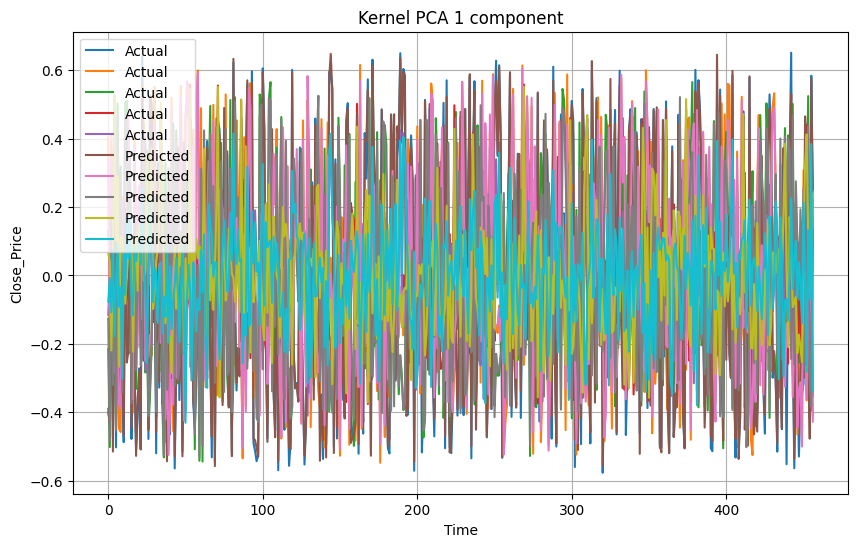

In [ ]:
import matplotlib.pyplot as plt

# Calculate the mean squared error
mse = model.evaluate(X_test, y_test)
print("Mean Squared Error:", mse)

# Make predictions
predictions = model.predict(X_test)

# Plot the actual vs. predicted values
plt.figure(figsize=(10, 6))
plt.plot(y_test, label='Actual')
plt.plot(predictions, label='Predicted')
plt.xlabel('Time')
plt.ylabel('Close_Price')
plt.title('Kernel PCA 1 component')
plt.legend()
plt.grid(True)
plt.show()